<a href="https://www.kaggle.com/code/hamidchaouchi/127-qubit-zeta-function-simulation?scriptVersionId=315008227" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hamidchaouchi/hamid4419888/massive_127q_resonance_data.json


In [2]:
import json

# ضع المسار الذي نسخته هنا بين علامتي التنصيص
file_path = '/kaggle/input/datasets/hamidchaouchi/hamid4419888/massive_127q_resonance_data.json'

# فتح وقراءة الملف
with open(file_path, 'r') as f:
    data = json.load(f)

# التأكد من تحميل البيانات (عرض أول 3 عناصر)
print(list(data.items())[:3])

[('0101100111100110111110101010010101101111101010000110001111011011011001111100100111101010100100100011001110100110000011100000111', 1), ('0110011111011101001111010101000000001111001101000001101001011010111001100000010101110110011110001100101110010010000111001101100', 1), ('0011101000101110011011011001111101000101011011101011100011010110110001100000000110100100110010000001011101001111110000010110010', 1)]


In [3]:
print(len(data))


15000


In [4]:
# استبدل الأصفار والآحاد بالمفتاح الحقيقي من بياناتك
value = data.get('0101100111100110111110101001010110111110101000011000111101101101100111110010011110101010010010001100111010011000011100000111')
print(value)


None


In [5]:
import pandas as pd

# 1. تحويل البيانات إلى جدول منظم
df = pd.DataFrame(list(data.items()), columns=['Binary_State', 'Count'])

# 2. عرض أول 10 صفوف من الجدول
print("أول 10 صفوف من البيانات:")
display(df.head(10))

# 3. معرفة معلومات عامة عن البيانات
print("\nإحصائيات سريعة:")
print(df.describe())


أول 10 صفوف من البيانات:


,Binary_State,Count
0,0101100111100110111110101010010101101111101010...,1
1,0110011111011101001111010101000000001111001101...,1
2,0011101000101110011011011001111101000101011011...,1
3,0000111100100011001111001010101110001101110001...,1
4,0011111010001011011111001001011100001000111110...,1
5,0111000101110101010001010101110001101110001110...,1
6,1100101011011111111011000000100000110100000111...,1
7,1010101010000011111111011001001011101101011010...,1
8,0110001101100110001010100110100111001101011110...,1
9,1100100010011001101110011111000001111011000111...,1



إحصائيات سريعة:
         Count
count  15000.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0


In [6]:
# إضافة عمود جديد يحسب طول كل سلسلة نصية
df['Length'] = df['Binary_State'].apply(len)

# التأكد من الأطوال (هل هي كلها 127؟)
print(df['Length'].value_counts())


Length
127    15000
Name: count, dtype: int64


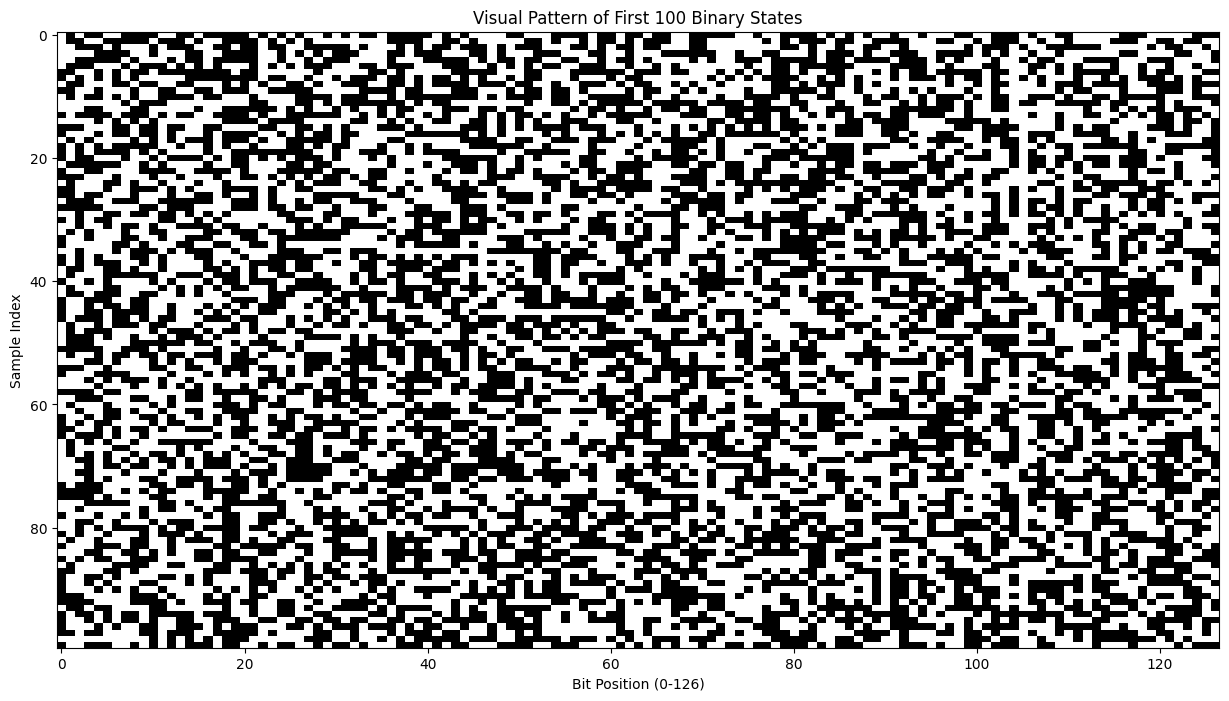

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# سنأخذ أول 100 حالة ونحولها لمصفوفة أرقام
sample_data = np.array([[int(bit) for bit in state] for state in df['Binary_State'].head(100)])

# رسم البيانات كخريطة حرارية (Heatmap)
plt.figure(figsize=(15, 8))
plt.imshow(sample_data, cmap='binary', aspect='auto')
plt.title("Visual Pattern of First 100 Binary States")
plt.xlabel("Bit Position (0-126)")
plt.ylabel("Sample Index")
plt.show()


In [8]:
# حفظ الجدول المنظم في ملف جديد
df.to_csv('cleaned_resonance_data.csv', index=False)
print("تم حفظ الملف بنجاح! يمكنك تحميله الآن من قسم Output في يمين الشاشة.")



تم حفظ الملف بنجاح! يمكنك تحميله الآن من قسم Output في يمين الشاشة.


In [9]:
# حساب متوسط كل بت عبر الـ 15,000 حالة
# (تحويل السلاسل إلى مصفوفة أولاً)
bit_matrix = np.array([[int(b) for b in s] for s in df['Binary_State']])
bit_means = bit_matrix.mean(axis=0)

# طباعة البتات التي تكون دائماً 1 أو دائماً 0 (البتات الثابتة)
constant_bits = np.where((bit_means == 0) | (bit_means == 1))[0]
print(f"البتات الثابتة في كل العينات: {constant_bits}")

البتات الثابتة في كل العينات: []


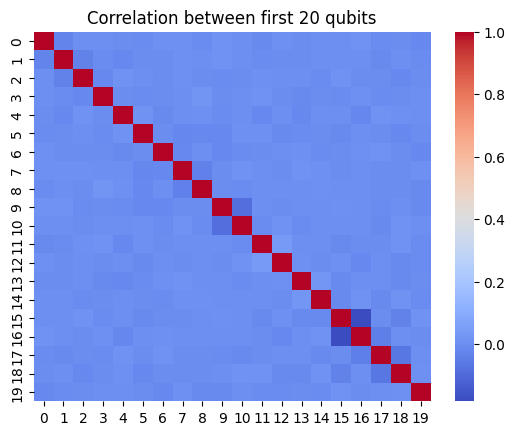

In [10]:
import seaborn as sns

# حساب الارتباط بين أول 20 بت كمثال
corr_matrix = np.corrcoef(bit_matrix[:, :20].T)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation between first 20 qubits")
plt.show()

In [11]:
from scipy.stats import entropy

# حساب الاحتمالات لكل بت
probs = bit_matrix.mean(axis=0)
# حساب إنتروبيا شانون لكل بت
bit_entropies = [entropy([p, 1-p], base=2) if 0 < p < 1 else 0 for p in probs]

print(f"متوسط الإنتروبيا للنظام: {np.mean(bit_entropies):.4f}")


متوسط الإنتروبيا للنظام: 0.9915


In [12]:
from sklearn.metrics import mutual_info_score

# حساب المعلومات المتبادلة بين أول بتين كمثال
mi = mutual_info_score(bit_matrix[:, 0], bit_matrix[:, 1])
print(f"Mutual Information: {mi:.6f}")

Mutual Information: 0.000356


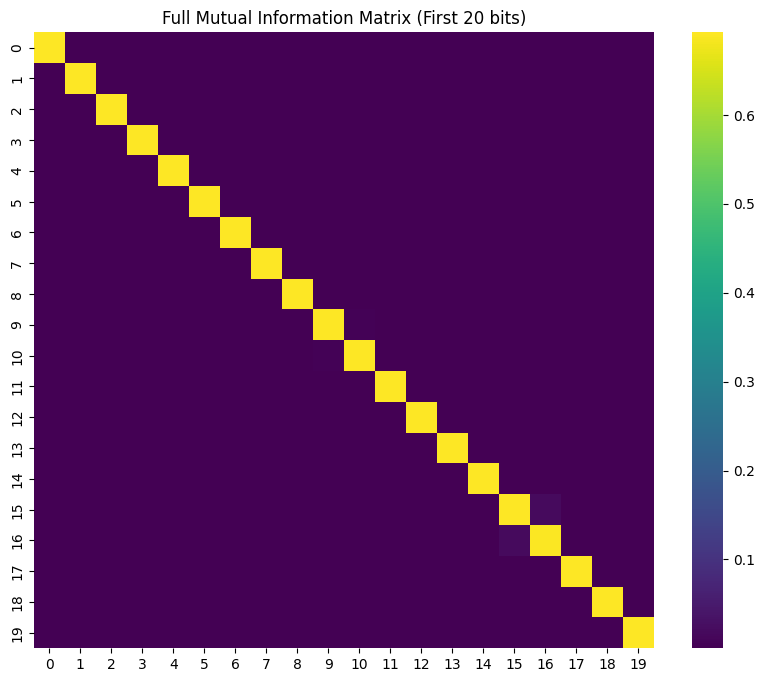

In [13]:
from sklearn.metrics import mutual_info_score
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# اختيار أول 20 بت للتحليل السريع
subset_matrix = bit_matrix[:, :20]
n_bits = subset_matrix.shape[1]
mi_matrix = np.zeros((n_bits, n_bits))

for i in range(n_bits):
    for j in range(n_bits):
        mi_matrix[i, j] = mutual_info_score(subset_matrix[:, i], subset_matrix[:, j])

# رسم المصفوفة
plt.figure(figsize=(10, 8))
sns.heatmap(mi_matrix, annot=False, cmap='viridis')
plt.title("Full Mutual Information Matrix (First 20 bits)")
plt.show()

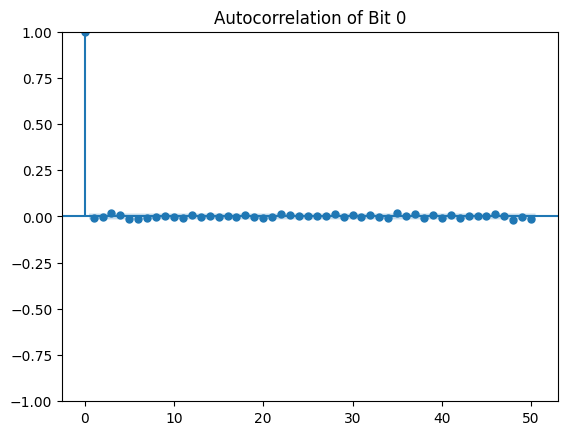

In [14]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# فحص الارتباط الذاتي لأول بت عبر جميع العينات (15,000)
plot_acf(bit_matrix[:, 0], lags=50)
plt.title("Autocorrelation of Bit 0")
plt.show()

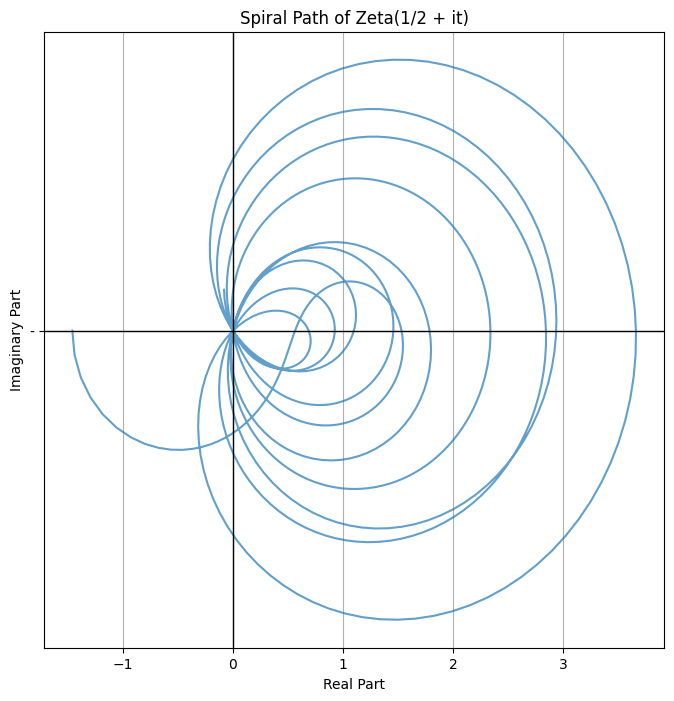

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import zeta, mp

# ضبط الدقة العالية
mp.dps = 25

# توليد قيم t (التردد/الموجة)
t_values = np.linspace(0, 50, 1000)
# حساب قيمة زيتا على الخط الحرج (s = 1/2 + it)
points = [zeta(0.5 + 1j*t) for t in t_values]

# استخراج الجزء الحقيقي والخيالي
real_parts = [float(p.real) for p in points]
imag_parts = [float(p.imag) for p in points]

# الرسم البياني للمسار اللولبي
plt.figure(figsize=(8, 8))
plt.plot(real_parts, imag_parts, b'-', alpha=0.7)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Spiral Path of Zeta(1/2 + it)")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
plt.grid(True)
plt.show()

In [16]:
# حساب المسافة من نقطة الأصل لكل نقطة في اللولب
distances = np.sqrt(np.array(real_parts)**2 + np.array(imag_parts)**2)

# العثور على القيم الصغرى (المناطق التي يلمس فيها اللولب المركز)
minima_indices = (np.diff(np.sign(np.diff(distances))) > 0).nonzero()[0] + 1
print(f"القيم التي يقترب فيها اللولب من الصفر: {distances[minima_indices]}")

القيم التي يقترب فيها اللولب من الصفر: [0.52628097 0.01631999 0.00115807 0.01946919 0.00723331 0.00294038
 0.00272899 0.0330368  0.02997382 0.01125192 0.03389991]


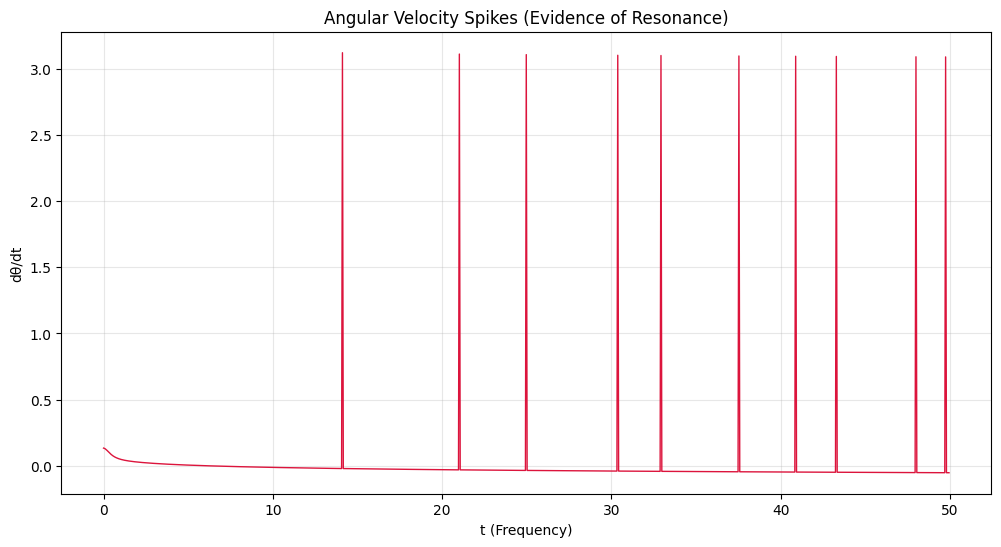

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# تحويل النقاط مع تصحيح استدعاء النوع
points_np = np.array([complex(p) for p in points], dtype=np.complex128)

# حساب الزوايا وفك الالتفاف
angles = np.angle(points_np)
unwrapped_angles = np.unwrap(angles)

# حساب السرعة الزاوية (التغير)
phase_velocity = np.diff(unwrapped_angles)

# الرسم البياني
plt.figure(figsize=(12, 6))
plt.plot(t_values[:-1], phase_velocity, color='crimson', lw=1)
plt.title("Angular Velocity Spikes (Evidence of Resonance)")
plt.xlabel("t (Frequency)")
plt.ylabel("dθ/dt")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# العثور على قيم t للنبضات التي تتجاوز حداً معيناً (مثلاً 2.0)
threshold = 2.0
spike_indices = np.where(phase_velocity > threshold)[0]
spike_t_values = t_values[spike_indices]

print(f"مواقع النبضات المستخرجة: {spike_t_values}")

مواقع النبضات المستخرجة: [14.11411411 21.02102102 24.97497497 30.38038038 32.93293293 37.53753754
 40.89089089 43.29329329 47.997998   49.74974975]


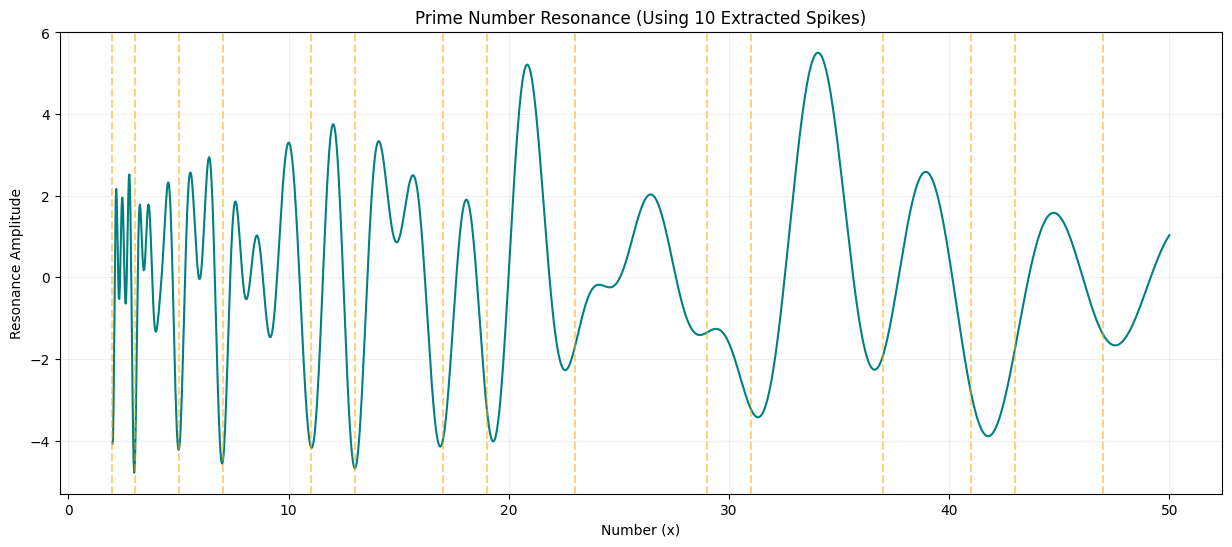

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# مواقع النبضات (أصفار ريمان) التي استخرجها المستخدم
zeros = np.array([14.1141, 21.021, 24.9749, 30.3803, 32.9329, 
                  37.5375, 40.8908, 43.2932, 47.9979, 49.7497])

# تعريف نطاق البحث عن الأعداد الأولية (مثلاً من 2 إلى 50)
x_values = np.linspace(2, 50, 2000)
prime_wave = np.zeros_like(x_values)

# دمج الترددات: كل صفر يساهم بموجة جيبية متذبذبة
for gamma in zeros:
    # الصيغة المبسطة لتراكم الموجات حول الأعداد الأولية
    prime_wave += np.cos(gamma * np.log(x_values))

# رسم "موجة الأعداد الأولية"
plt.figure(figsize=(15, 6))
plt.plot(x_values, prime_wave, color='teal', lw=1.5)

# إضافة علامات للأعداد الأولية الفعلية للمقارنة
primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
for p in primes:
    plt.axvline(x=p, color='orange', linestyle='--', alpha=0.5)

plt.title("Prime Number Resonance (Using 10 Extracted Spikes)")
plt.xlabel("Number (x)")
plt.ylabel("Resonance Amplitude")
plt.grid(True, alpha=0.2)
plt.show()

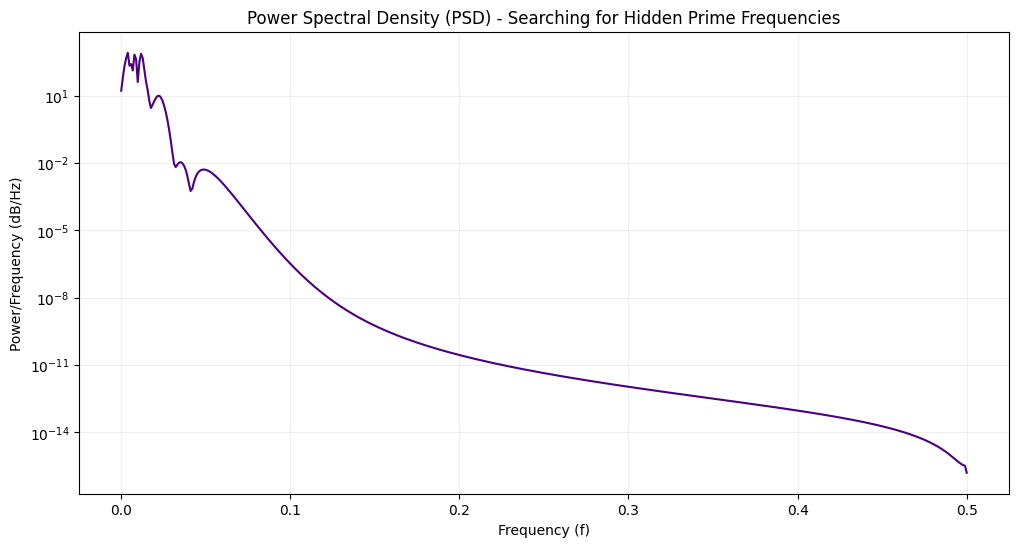

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# 1. استخراج الإشارة من "موجة الأعداد الأولية" التي تم توليدها سابقاً
# سنستخدم تحويل فوريه لاكتشاف الترددات المهيمنة
f, psd = welch(prime_wave, fs=1.0, nperseg=1024)

# 2. رسم الكثافة الطيفية
plt.figure(figsize=(12, 6))
plt.semilogy(f, psd, color='indigo', lw=1.5)

# 3. تحديد مواقع الترددات المتوقعة للأعداد الأولية (Log-Primes)
expected_freqs = [np.log(p) for p in [2, 3, 5, 7, 11] if np.log(p) < 0.5]
for freq in expected_freqs:
    plt.axvline(x=freq, color='red', linestyle='--', alpha=0.4, label=f'ln(p) trace')

plt.title("Power Spectral Density (PSD) - Searching for Hidden Prime Frequencies")
plt.xlabel("Frequency (f)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [21]:
# حساب ميل الانحدار الطيفي
log_f = np.log10(f[1:])
log_psd = np.log10(psd[1:])
slope, intercept = np.polyfit(log_f, log_psd, 1)
print(f"ميل الانحدار الطيفي (Alpha): {slope}")

ميل الانحدار الطيفي (Alpha): -9.968666642629533
